# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

c:\Users\brett\projects\github\bretttay24\cosc-650-applied-llm-systems\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 9935.08it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = """The most famous movie star in 2026 is"""   # TODO (you): your own short prompt
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 749, 5863, 3807, 3491, 287, 1160, 2075, 318]
  pos 0: id    464 -> 'The'
  pos 1: id    749 -> ' most'
  pos 2: id   5863 -> ' famous'
  pos 3: id   3807 -> ' movie'
  pos 4: id   3491 -> ' star'
  pos 5: id    287 -> ' in'
  pos 6: id   1160 -> ' 20'
  pos 7: id   2075 -> '26'
  pos 8: id    318 -> ' is'

embedded prompt shape (seq_len, dim): (9, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.297
  ' most'      0.126
  ' famous'    0.123
  ' movie'     0.149
  ' star'      0.089
  ' in'        0.034
  ' 20'        0.072
  '26'         0.067
  ' is'        0.043

logits shape (batch, seq, vocab): (1, 9, 50257)
top 10 next tokens:
  ' the'         0.0772
  ' James'       0.0393
  ' John'        0.0225
  ' George'      0.0187
  ' a'           0.0187
  ' Robert'      0.0179
  ' Harry'       0.0146
  ' The'         0.0119
  ' Henry'       0.0112
  ' William'     0.0111


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

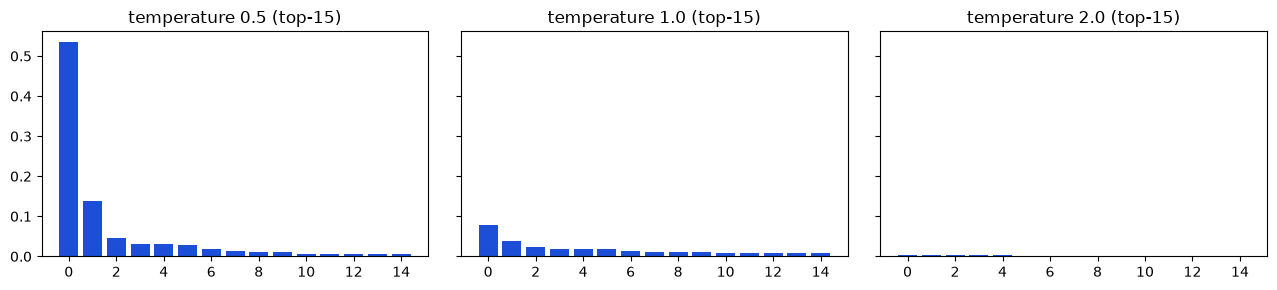

top token prob: temp 0.5 = 0.535, temp 1.0 = 0.077, temp 2.0 = 0.005


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
# TODO (you): for each row, write what you predicted versus what you see.

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 4.161, max prob 0.257, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 7.761, max prob 0.027, nucleus keeps 4394 tokens



### Part 3 Predictions vs Actual

#### Row 1
**temp** = 1e-6 | **top-p** = 1.0

**Prediction**: When reading the temperature of 0 and a top-p of 1 I interpret this as a decisive/sharp distribution with less randomness. The probaitlity of tokens in the nucleus kept by the top parameter will have to add up to about the probability of 1. I would guess a count of 3-5 tokens, with a max probability in the .80s. In part 2 of this project, I can see a temp of 0.5 with a max probability of 0.53. The entropy would be close since there are fewer tokens. 

**Actual output**: I guessed the general trend correctly. I was suprised to see 1 word being kept by the nucleus. This is lower than I predicted. But I should not be suprised because this is essentailly deterministic. The max probability of being 1 suprised me as well. 

---

#### Row 2
**temp** = 0.7 | **top-p** = 1.0

**Prediction**: If I am referencing the graph in part 2 a temperature of 0.7 is somewhere between the first two graphs (from left to right). I guess there will be a max probability of 0.4 - 0.3. There will be more tokens remaining to reach the nucleus that adds up to a proability of 1. The dictionary is has a vocab size of 50257 so I would guess to add up to a probability of 1.0 we would have most of the vocabularly. The entropy will be higher than the first group because more values will have lower proabilities being added to make the proability = 1.0.

**Actual output**:  I see that the max proability was lower than my guess (of 0.4-0.3). I am a bit confused how a an embedding model with a vocabulary of 50257 creates a nucleus of 50258. I will go assume this is a bug. My understanding is that LLMs create a logit which is normalized to a probability for each token in the vocabulary and therefore it could not have a nuclues greater than 50257. 

---

#### Row 3
**temp** = 1.3 | **top-p** = 0.9

**Prediction**: With this run I predict that the max proability will be lower than the previous two runs. I could see the entropy being higher as well. Trying to guess the amount of tokens the nucleus keeps is difficult because we have a vocab of 50257, but our probabilities need to add up to 0.9 rather than 1. This will be fewer tokens than row 2 and less than row 1. If I had to guess a number I would say 30 thousand? That would leave over 20000 tokens being required to take the proability from .9 to 1.

**Actual output**: 
I guessed the general trend correctly, but I was very wrong on nucleus size. The actual requires 4,394 tokens to get the probability of of 0.9. I was also suprised to see the max proability at 0.027. This lower than my intuition would have guess without having run this before. But reflecting on the graphs in part 2 of the project would have gotten me closer to an accurate guess. The graph and output beneath it show that a temperature of 1 the max token proability is 0.077. So it would make sense for a temperature at 1.3 to have even smaller max prob. 

## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

temp -> 0: top token prob = 1.0 (greedy collapse)

======== Top-k probabilities before and after renormalization ========

temp 0.5: same top-10 tokens before and after renormalization
rank  token             before renorm   after renorm
   1  ' the'                 0.534887       0.618945
   2  ' James'               0.138514       0.160282
   3  ' John'                0.045308       0.052428
   4  ' George'              0.031438       0.036378
   5  ' a'                   0.031372       0.036302
   6  ' Robert'              0.028827       0.033357
   7  ' Harry'               0.019016       0.022004
   8  ' The'                 0.012632       0.014618
   9  ' Henry'               0.011203       0.012963
  10  ' William'             0.010995       0.012723
    probability sum before renormalization = 0.864191
    probability sum after renormalization = 1.000000
    median probability = 0.034829; mean probability = 0.100000; probability standard deviation = 0.177852
    kept probabilit

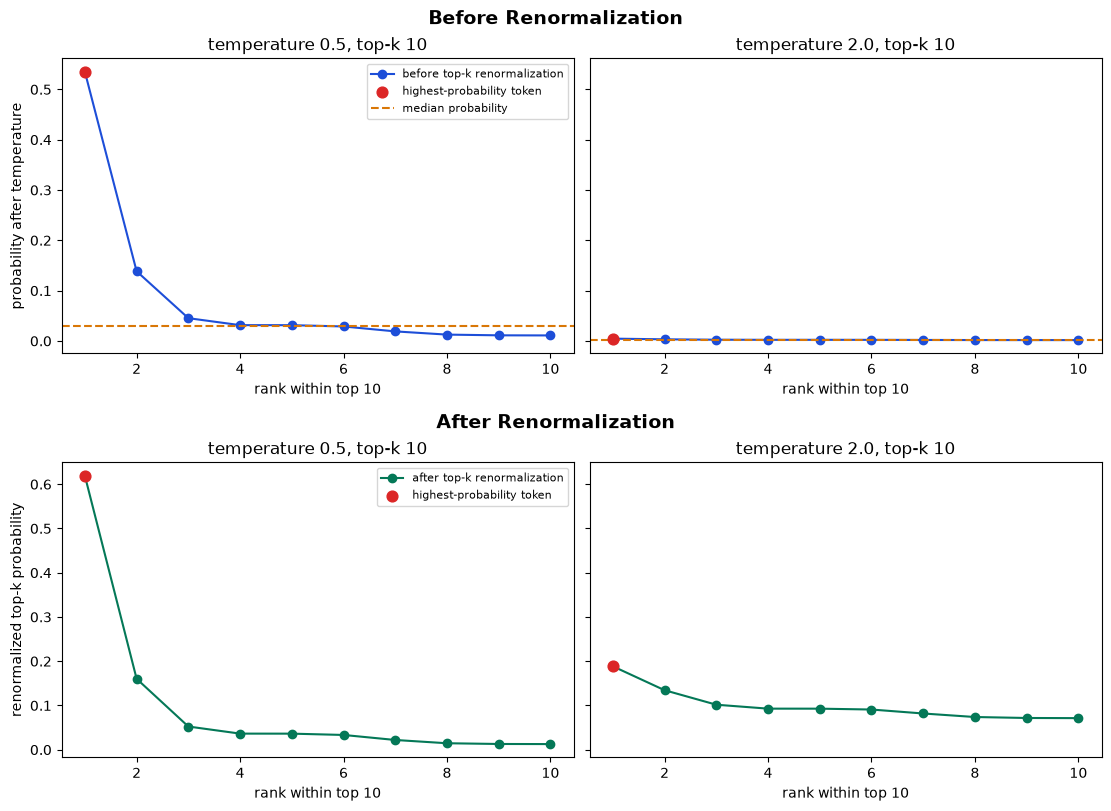

In [5]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)')
# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.
print()
print('======== Top-k probabilities before and after renormalization ========')
temperatures = (0.5, 2.0)
top_k_count = 10
fig = plt.figure(figsize=(11, 8), layout='constrained')
before_figure, after_figure = fig.subfigures(2, 1)
before_figure.suptitle('Before Renormalization', fontsize=14, fontweight='bold')
after_figure.suptitle('After Renormalization', fontsize=14, fontweight='bold')
before_axes = before_figure.subplots(1, 2, sharey=True)
after_axes = after_figure.subplots(1, 2, sharey=True)

for before_ax, after_ax, t in zip(before_axes, after_axes, temperatures):
    p = temperature(z, t)
    top_indices = np.argsort(p)[::-1][:top_k_count]
    filtered_p = top_k(p, top_k_count)
    raw_probabilities = p[top_indices]
    renormalized_probabilities = filtered_p[top_indices]

    print(f'\ntemp {t}: same top-{top_k_count} tokens before and after renormalization')
    print(f'{"rank":>4}  {"token":<16} {"before renorm":>14} {"after renorm":>14}')
    for rank, (token_id, raw_probability, final_probability) in enumerate(
        zip(top_indices, raw_probabilities, renormalized_probabilities), start=1
    ):
        print(f'{rank:>4}  {tok.decode([int(token_id)])!r:<16} {raw_probability:>14.6f} {final_probability:>14.6f}')
    print(f'    probability sum before renormalization = {raw_probabilities.sum():.6f}')
    print(f'    probability sum after renormalization = {renormalized_probabilities.sum():.6f}')
    print(f'    median probability = {np.median(renormalized_probabilities):.6f}; mean probability = {renormalized_probabilities.mean():.6f}; probability standard deviation = {renormalized_probabilities.std():.6f}')
    print(f'    kept probability range = {np.ptp(renormalized_probabilities):.6f}; lowest kept probability = {renormalized_probabilities.min():.6f}')

    ranks = np.arange(1, top_k_count + 1)
    before_ax.plot(ranks, raw_probabilities, marker='o', color='#1d4ed8', label='before top-k renormalization')
    before_ax.scatter(1, raw_probabilities[0], color='#dc2626', s=60, zorder=3, label='highest-probability token')
    before_ax.axhline(np.median(raw_probabilities), color='#d97706', linestyle='--', label='median probability')
    before_ax.set_title(f'temperature {t}, top-k {top_k_count}')
    before_ax.set_xlabel('rank within top 10')

    after_ax.plot(ranks, renormalized_probabilities, marker='o', color='#047857', label='after top-k renormalization')
    after_ax.scatter(1, renormalized_probabilities[0], color='#dc2626', s=60, zorder=3, label='highest-probability token')
    after_ax.set_title(f'temperature {t}, top-k {top_k_count}')
    after_ax.set_xlabel('rank within top 10')

before_axes[0].set_ylabel('probability after temperature')
after_axes[0].set_ylabel('renormalized top-k probability')
before_axes[0].legend(fontsize=8)
after_axes[0].legend(fontsize=8)
plt.show()

### My surprising case: fixed top-k at different temperatures

For my surprising case, I kept **top-k** constant and changed the **temperature**. Before explaining the result, I want to spell out what each term means.

- **Logits** are the raw scores produced by the model for every token in its vocabulary. Softmax converts those logits into probabilities that sum to 1.
- **Temperature** changes the shape of that probability distribution. A lower temperature such as `0.5` makes the distribution sharper, so a few tokens receive most of the probability. A higher temperature such as `2.0` flattens the distribution, so the probability is spread across many more tokens.
- **Top-k** keeps exactly the `k` tokens with the highest probabilities and removes every other token. In this experiment, `k=10`, so only 10 tokens remain available for sampling regardless of how sharp or flat the distribution is.
- **Probability mass** is the sum of the probabilities of the tokens that remain. For example, if the retained token probabilities add up to `0.50`, those tokens contain 50% of the original probability mass.
- **Renormalization** divides each retained probability by the retained probability mass so that the remaining probabilities sum to 1. The code does not apply softmax a second time. It rescales probabilities that were already produced by softmax.

At temperature `0.5`, the top 10 tokens contain `0.864191` probability mass. This means those 10 tokens already represent about 86.4% of the original distribution. Keeping only those tokens is restrictive, but it still preserves most of the probability the model assigned.

At temperature `2.0`, the same top 10 tokens contain only `0.024412` probability mass. This means they represent only about 2.4% of the original distribution, while approximately 97.6% is removed. Top-k then renormalizes that small remaining portion to sum to 1. For example, the highest token changes from probability `0.004602` before renormalization to `0.188520` afterward. The token looks much more likely in the final sampling distribution even though its original probability was less than one percent.

This was surprising because increasing temperature is supposed to allow more variety, but fixed top-k still limits sampling to exactly 10 tokens. Temperature changes their probabilities, but it does not change their ranking, so the same 10 tokens remain eligible. The high temperature spreads probability across the vocabulary, and then top-k immediately removes almost all of that spread. This does not remove all randomness, but it restricts the randomness much more than I intended.

### Mitigation with top-p

**Top-p** keeps the smallest possible group of tokens whose probabilities add up to at least `p`. In simple terms, it keeps only as many of the most likely tokens as needed to reach the chosen probability target. In this experiment, `top_p=0.50`, so top-p keeps the smallest group whose probabilities total at least 50%.

It works step by step: first, sort all tokens from highest to lowest probability. Then, start with the most likely token and add one token at a time. Stop as soon as the running total reaches or passes `p`. At temperature `2.0`, 1,983 tokens were needed to reach `p=0.50`. Their probabilities added up to `0.500070`, slightly more than 50% because the last whole token pushed the total over the target. Finally, the retained probabilities were renormalized so they summed to 1.

Top-p mitigates the fixed-cutoff problem because it adapts to the shape of the distribution. A sharp distribution may need only a few tokens to reach the target mass, while a flat distribution may need many tokens. In this case, top-p preserves the broader set of choices created by the high temperature instead of always forcing the model to choose from only 10 tokens.

temperature = 2.0
top-p = 0.50
tokens retained = 1983
probability sum before renormalization = 0.500070
probability sum after renormalization = 1.000000


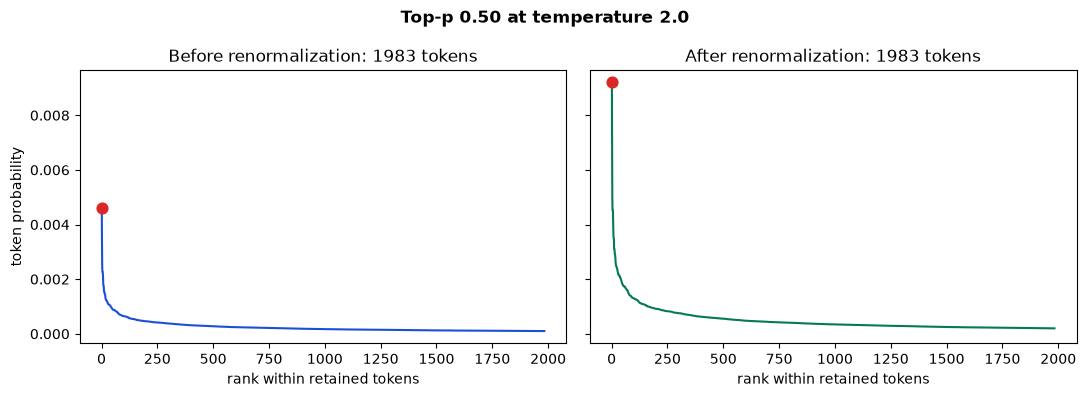

In [6]:
comparison_temperature = 2.0
comparison_top_p = 0.50

p = temperature(z, comparison_temperature)
top_p_distribution, top_p_kept = top_p(p, comparison_top_p)
retained_mask = top_p_distribution > 0
before_renormalization = np.sort(p[retained_mask])[::-1]
after_renormalization = np.sort(top_p_distribution[retained_mask])[::-1]
ranks = np.arange(1, top_p_kept + 1)

print(f'temperature = {comparison_temperature}')
print(f'top-p = {comparison_top_p:.2f}')
print(f'tokens retained = {top_p_kept}')
print(f'probability sum before renormalization = {before_renormalization.sum():.6f}')
print(f'probability sum after renormalization = {after_renormalization.sum():.6f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(ranks, before_renormalization, color='#1d4ed8')
axes[0].scatter(1, before_renormalization[0], color='#dc2626', s=60, zorder=3)
axes[0].set_title(f'Before renormalization: {top_p_kept} tokens')
axes[0].set_xlabel('rank within retained tokens')
axes[0].set_ylabel('token probability')

axes[1].plot(ranks, after_renormalization, color='#047857')
axes[1].scatter(1, after_renormalization[0], color='#dc2626', s=60, zorder=3)
axes[1].set_title(f'After renormalization: {top_p_kept} tokens')
axes[1].set_xlabel('rank within retained tokens')

fig.suptitle(f'Top-p {comparison_top_p:.2f} at temperature {comparison_temperature}', fontweight='bold')
plt.tight_layout(); plt.show()

## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).